In [1]:
from pathlib import Path
import sys

project_root = Path.cwd().parent
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

%load_ext IPython.extensions.autoreload
%autoreload 2

import cv2
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

from stresscam.preprocessing.face_detection import FaceDetector
from stresscam.preprocessing.skin_segmentation import SkinSegmenter
from stresscam.preprocessing.rgb_extraction import RGBExtractor

In [2]:
video_path = (
    project_root
    / "data"
    / "raw"
    / "UBFC_Phys"
    / "s46"
    / "vid_s46_T1.avi"
)

cap = cv2.VideoCapture(str(video_path))
n_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

print(cap.isOpened())

True


In [3]:
detector = FaceDetector()
segmenter = SkinSegmenter()
extractor = RGBExtractor()

In [4]:
rgb_trace = []

failed = 0
processed = 0

pbar = tqdm(
    total=n_frames, 
    desc="Processing frames", 
    unit="frames", 
    ncols=100,
    colour="green"
)

while True:

    ret, frame = cap.read()

    if not ret:
        break

    # Face Detection
    det_results = detector.detect(frame)

    face = detector.crop(frame, det_results)

    if face is None:
        failed += 1
        continue

    # Face Mesh
    mask, mesh_results = segmenter.segment(face)

    if mask is None:
        failed += 1
        continue

    # RGB Extraction
    rgb = extractor.extract(face, mask)

    rgb_trace.append(rgb)

    processed += 1
    
    pbar.update(1)

pbar.close()
cap.release()

rgb_trace = np.array(rgb_trace)

print(rgb_trace.shape)
print("Processed:", processed)
print("Failed:", failed)

Processing frames:   0%|                                               | 0/6325 [00:00<?, ?frames/s]c:\Users\lason\.conda\envs\stresscam\Lib\site-packages\google\protobuf\symbol_database.py:55: UserWarning: SymbolDatabase.GetPrototype() is deprecated. Please use message_factory.GetMessageClass() instead. SymbolDatabase.GetPrototype() will be removed soon.
  warnings.warn('SymbolDatabase.GetPrototype() is deprecated. Please '
Processing frames: 100%|████████████████████████████████████| 6325/6325 [03:37<00:00, 29.11frames/s]

(6325, 3)
Processed: 6325
Failed: 0


In [5]:
R = rgb_trace[:, 0]
G = rgb_trace[:, 1]
B = rgb_trace[:, 2]

In [6]:
fps = 35

t = np.arange(len(R)) / fps

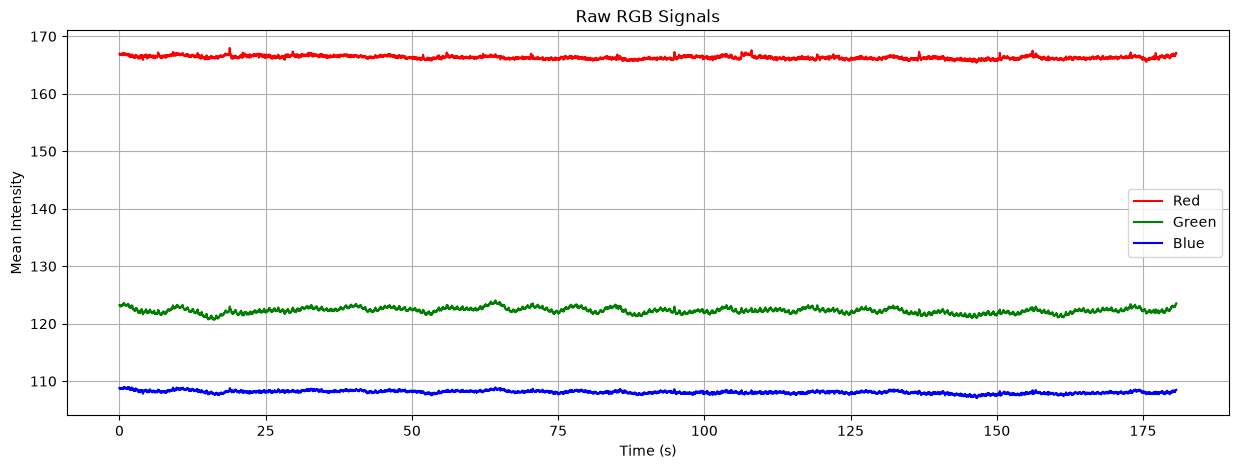

In [8]:
plt.figure(figsize=(15,5))

plt.plot(t, R, label="Red", color='r')
plt.plot(t, G, label="Green", color='g')
plt.plot(t, B, label="Blue", color='b')

plt.xlabel("Time (s)")
plt.ylabel("Mean Intensity")
plt.title("Raw RGB Signals")

plt.legend()
plt.grid(True)
plt.show()

In [9]:
from scipy.ndimage import uniform_filter1d

window = int(fps)      # 1-second running mean

R_dt = R - uniform_filter1d(R, size=window)
G_dt = G - uniform_filter1d(G, size=window)
B_dt = B - uniform_filter1d(B, size=window)

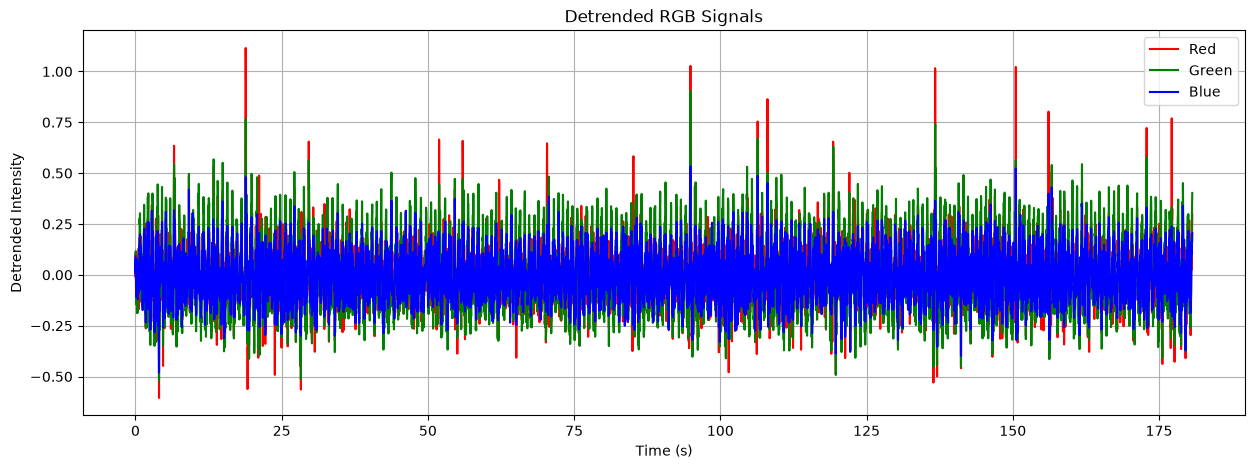

In [10]:
plt.figure(figsize=(15,5))

plt.plot(t, R_dt, color="red", label="Red")
plt.plot(t, G_dt, color="green", label="Green")
plt.plot(t, B_dt, color="blue", label="Blue")

plt.xlabel("Time (s)")
plt.ylabel("Detrended Intensity")
plt.title("Detrended RGB Signals")

plt.legend()
plt.grid(True)
plt.show()

In [11]:
from scipy.signal import butter, filtfilt


def bandpass(signal, fs, low=0.7, high=3.5, order=3):
    nyquist = 0.5 * fs

    b, a = butter(
        order,
        [low / nyquist, high / nyquist],
        btype="band",
    )

    return filtfilt(b, a, signal)

In [18]:
R_bp = bandpass(R_dt, fps)
G_bp = bandpass(G_dt, fps)
B_bp = bandpass(B_dt, fps)

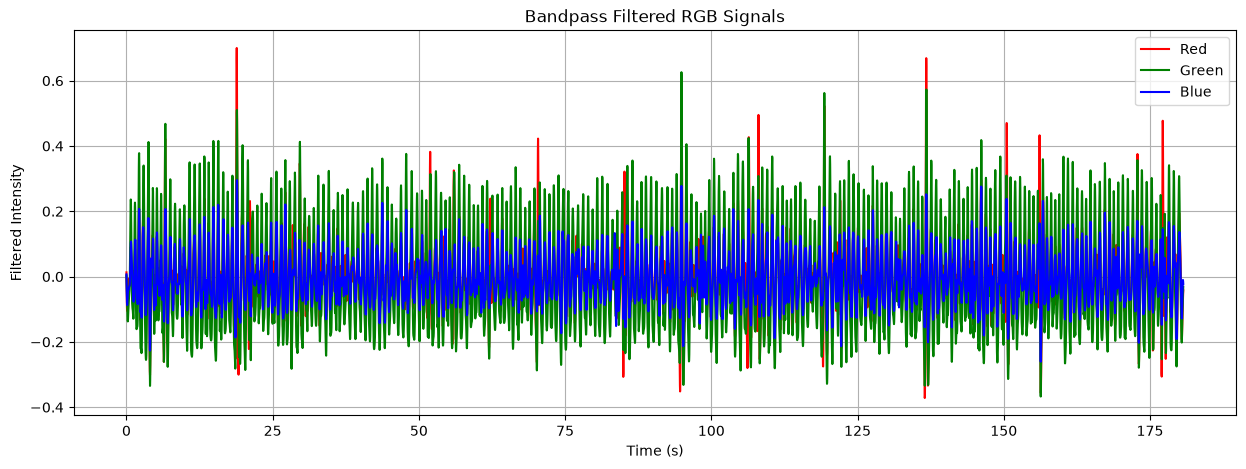

In [19]:
plt.figure(figsize=(15,5))

plt.plot(t, R_bp, color="red", label="Red")
plt.plot(t, G_bp, color="green", label="Green")
plt.plot(t, B_bp, color="blue", label="Blue")

plt.xlabel("Time (s)")
plt.ylabel("Filtered Intensity")
plt.title("Bandpass Filtered RGB Signals")

plt.legend()
plt.grid(True)

plt.show()

In [20]:
from stresscam.rppg.pos import pos

rgb = rgb_trace
pulse = pos(rgb, fps)

pulse = pos(rgb, fps)

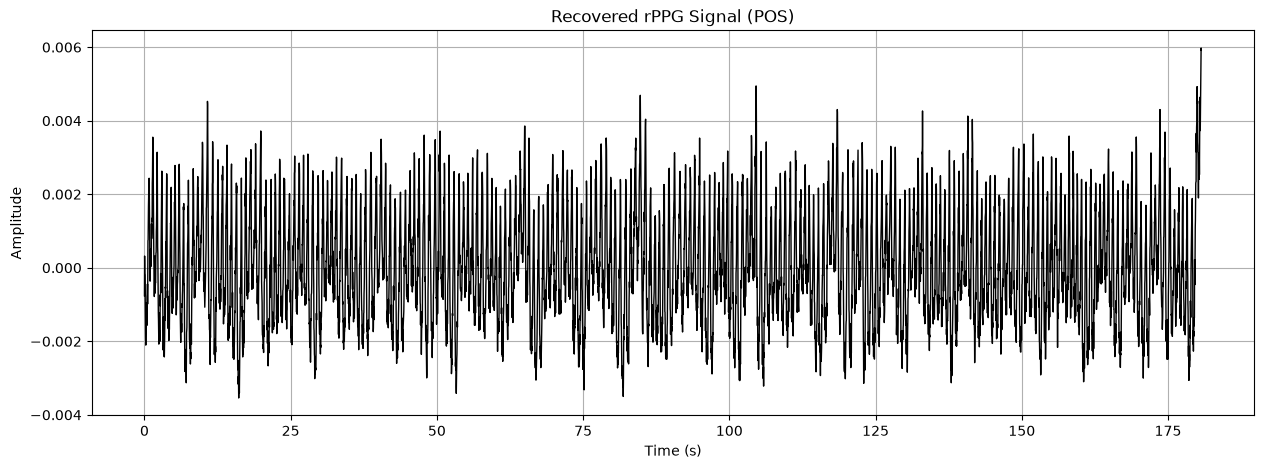

In [24]:
plt.figure(figsize=(15,5))

plt.plot(t, pulse, color="black", linewidth=1)

plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.title("Recovered rPPG Signal (POS)")
plt.grid(True)

plt.show()

#### Load BVP

In [25]:
bvp_path = (
    project_root
    / "data"
    / "raw"
    / "UBFC_Phys"
    / "s46"
    / "bvp_s46_T1.csv"
)

bvp = np.loadtxt(bvp_path)

In [26]:
print(bvp.shape)
print(len(pulse))

(11520,)
6325


#### Resample BVP to video FPS

In [27]:
from scipy.signal import resample

bvp_resampled = resample(bvp, len(pulse))

print(len(bvp_resampled))

6325


#### Normalize both

In [28]:
from scipy.stats import zscore

pulse_z = zscore(pulse)
bvp_z = zscore(bvp_resampled)

Plot a 10-second segment

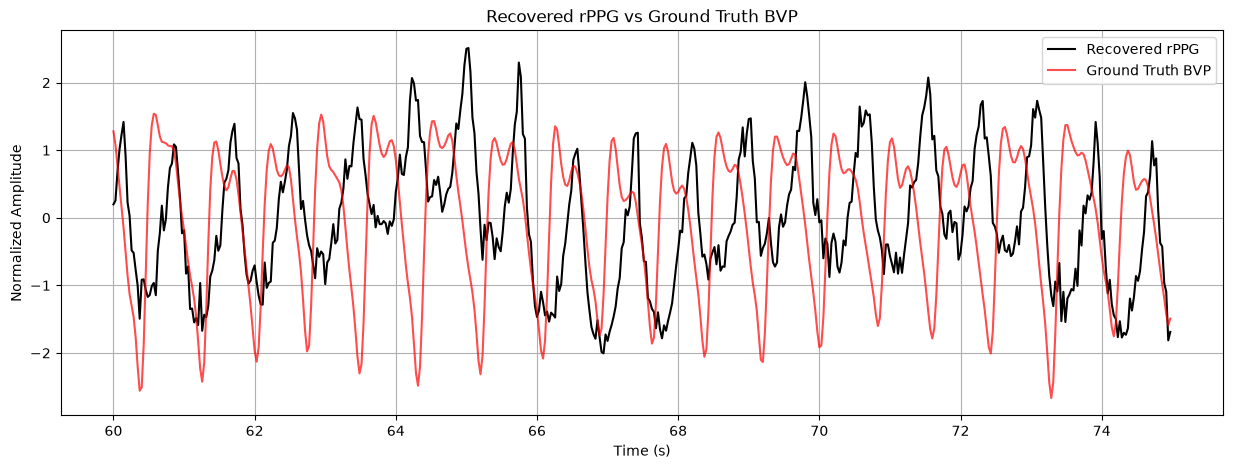

In [32]:
start_sec = 60
duration = 15

start = int(start_sec * fps)
end = int((start_sec + duration) * fps)

plt.figure(figsize=(15,5))

plt.plot(
    t[start:end],
    pulse_z[start:end],
    color="black",
    label="Recovered rPPG",
)

plt.plot(
    t[start:end],
    bvp_z[start:end],
    color="red",
    alpha=0.7,
    label="Ground Truth BVP",
)

plt.xlabel("Time (s)")
plt.ylabel("Normalized Amplitude")
plt.title("Recovered rPPG vs Ground Truth BVP")

plt.grid(True)
plt.legend()

plt.show()

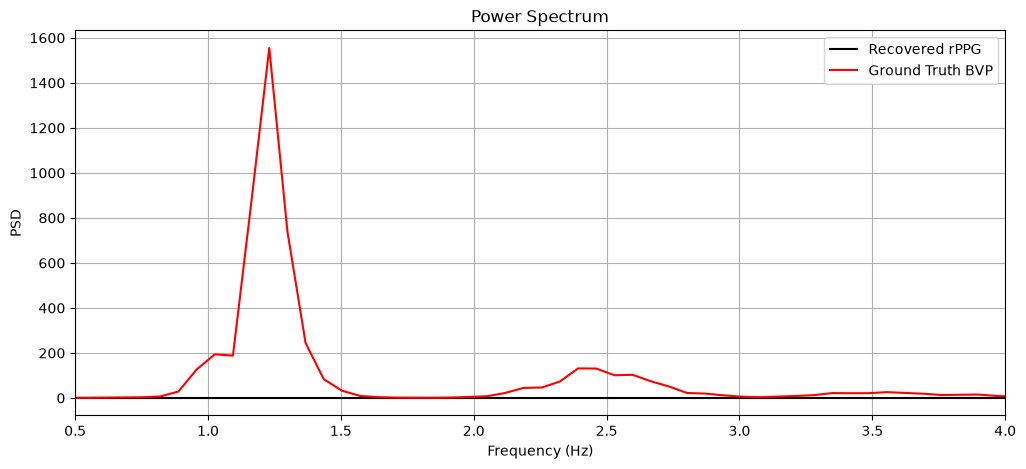

In [47]:
from scipy.signal import welch

f_rppg, p_rppg = welch(
    pulse,
    fs=fps,
    nperseg=512,
)

f_bvp, p_bvp = welch(
    bvp_resampled,
    fs=fps,
    nperseg=512,
)

plt.figure(figsize=(12,5))

plt.plot(f_rppg, p_rppg, color="black", label="Recovered rPPG")
plt.plot(f_bvp, p_bvp, color="red", label="Ground Truth BVP")

plt.xlim(0.5, 4)

plt.xlabel("Frequency (Hz)")
plt.ylabel("PSD")
plt.title("Power Spectrum")

plt.grid(True)
plt.legend()

plt.show()

- rPPG magnitude is very less so comparatively it looks flat

---

- Below after normalization plots can be seen to have similar freq profile.

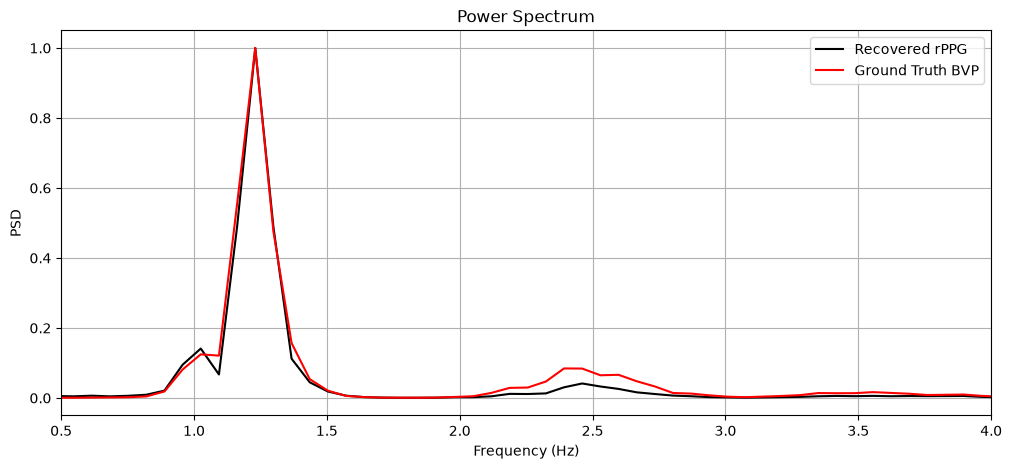

In [48]:

plt.figure(figsize=(12,5))

plt.plot(
    f_rppg,
    p_rppg / np.max(p_rppg),
    color="black",
    label="Recovered rPPG",
)

plt.plot(
    f_bvp,
    p_bvp / np.max(p_bvp),
    color="red",
    label="Ground Truth BVP",
)

plt.xlim(0.5, 4)

plt.xlabel("Frequency (Hz)")
plt.ylabel("PSD")
plt.title("Power Spectrum")

plt.grid(True)
plt.legend()

plt.show()

In [34]:
freq_rppg = f_rppg[np.argmax(p_rppg)]
freq_bvp = f_bvp[np.argmax(p_bvp)]

print("rPPG HR :", freq_rppg * 60, "BPM")
print("BVP HR  :", freq_bvp * 60, "BPM")

rPPG HR : 73.828125 BPM
BVP HR  : 73.828125 BPM
